Initializing Depth Anything V2 Large pipeline components...


preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.34GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

Loaded source frame resolution: 1536x1536
Executing single-frame prediction step...


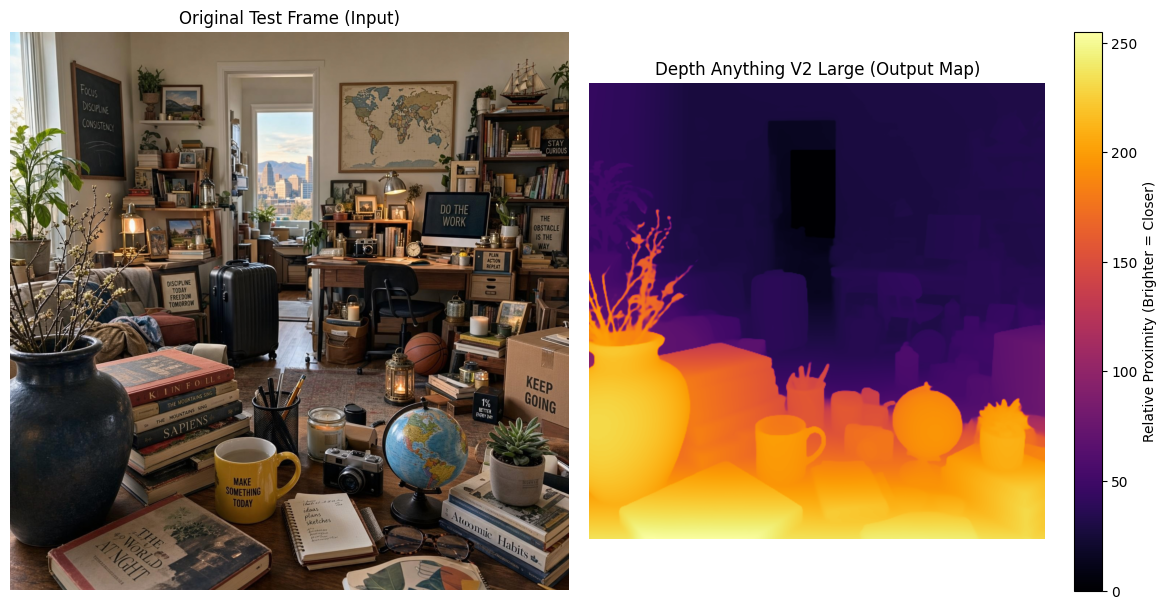

Execution completed. Prediction asset saved successfully to disk as: 'depth_anything_v2_large_output.png'


In [2]:
# Environment configuration and path specifications
import os
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# Target runtime environment hardware setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_PATH = "depth.jpg"
OUTPUT_PATH = "depth_anything_v2_large_output.png"

# Verify image existence before loading components
if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Missing baseline asset: Please upload '{IMAGE_PATH}' to Colab storage.")

# Load specialized preprocessor and neural architecture weights
print("Initializing Depth Anything V2 Large pipeline components...")
processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Large-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Large-hf")
model.to(DEVICE).eval()

# Execute structural half-precision optimization if running on T4 GPU
if DEVICE.type == "cuda":
    model = model.half()

# Load and preprocess raw source image
raw_image = Image.open(IMAGE_PATH).convert("RGB")
original_width, original_height = raw_image.size
print(f"Loaded source frame resolution: {original_width}x{original_height}")

# Format inputs according to the model transformation protocol
inputs = processor(images=raw_image, return_tensors="pt").to(DEVICE)
if DEVICE.type == "cuda":
    inputs = {k: v.half() if torch.is_floating_point(v) else v for k, v in inputs.items()}

# Execute feed-forward execution path without gradient tracking
print("Executing single-frame prediction step...")
with torch.no_grad():
    outputs = model(**inputs)
    # The model outputs raw spatial feature maps representing relative inverse depth
    predicted_depth = outputs.predicted_depth

# Interpolate the low-resolution prediction back to the original source resolution
# Using standard bilinear interpolation for boundary smoothness
interpolated_depth = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=(original_height, original_width),
    mode="bilinear",
    align_corners=False,
).squeeze()

# Convert tensor arrays into local CPU memory layouts
depth_map = interpolated_depth.cpu().numpy()

# Min-Max Normalization: transform raw scale into stable 8-bit integer space
depth_min = depth_map.min()
depth_max = depth_map.max()
normalized_depth = (depth_map - depth_min) / (depth_max - depth_min + 1e-8)
uint8_depth = (normalized_depth * 255).astype(np.uint8)

# Save the raw single-channel depth mask
cv2.imwrite("raw_depth_mask.png", uint8_depth)

# Visual presentation setup using Matplotlib
plt.figure(figsize=(12, 6))

# Plot source baseline input image
plt.subplot(1, 2, 1)
plt.imshow(raw_image)
plt.title("Original Test Frame (Input)")
plt.axis("off")

# Plot standard colorized predictive depth representation
plt.subplot(1, 2, 2)
plt.imshow(uint8_depth, cmap="inferno")
plt.title("Depth Anything V2 Large (Output Map)")
plt.colorbar(label="Relative Proximity (Brighter = Closer)")
plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Execution completed. Prediction asset saved successfully to disk as: '{OUTPUT_PATH}'")
